# Part III: Downstream Task with Learned Representations (30 pts)

Use representations from trained LMs for 4-class AG News classification.

Compare:
- BoW + LogisticRegression baseline
- Frozen LM + linear probe
- Frozen LM + MLP
- Fine-tuned LM + linear head

Using RNN, LSTM, and Transformer as LM backbones.

In [2]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.utils import load_config, set_seed, get_device, plot_confusion_matrix, load_model
from src.data import prepare_data, build_cls_dataloaders, build_lm_dataloaders
from src.rnn_lm import RNNLM
from src.lstm_lm import LSTMLM
from src.transformer_lm import TransformerLM
from src.downstream import (
    extract_features, train_frozen_classifier, train_finetune_classifier,
    bow_baseline, full_evaluation, LMClassifier, AG_NEWS_CLASSES,
)
from src.sanity import check_feature_stats

config = load_config('../configs/default.yaml')
set_seed(config['seed'])
device = get_device()
print(f'Device: {device}')

Device: cuda


In [3]:
data = prepare_data(config)
vocab = data['vocab']
cfg_data = config['data']
cfg_model = config['model']
cfg_ds = config['downstream']

Loading AG News dataset...
Tokenizing...
Building vocabulary...
  Vocabulary size: 20000
Encoding sequences...


## 1. BoW + Logistic Regression Baseline

In [4]:
bow_results = bow_baseline(
    data['train_texts'], data['train_labels'],
    data['hf_test_texts'], data['hf_test_labels'],
)
print(f"BoW Baseline Test Accuracy: {bow_results['test_acc']:.4f}")
print(bow_results['classification_report'])

Training BoW + LogisticRegression baseline...


c:\Users\ngjun\anaconda3\envs\tictag\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


BoW Baseline Test Accuracy: 0.9022
              precision    recall  f1-score   support

       World       0.91      0.90      0.91      1900
      Sports       0.96      0.97      0.96      1900
    Business       0.87      0.86      0.86      1900
    Sci/Tech       0.88      0.88      0.88      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



In [4]:
# Class distribution and baselines
from collections import Counter

train_dist = Counter(data['train_labels'])
test_dist = Counter(data['hf_test_labels'])

print('--- Class Distribution ---')
print('Train:')
for cls_idx, cls_name in enumerate(AG_NEWS_CLASSES):
    print(f'  {cls_name}: {train_dist[cls_idx]} ({train_dist[cls_idx]/len(data["train_labels"])*100:.1f}%)')

print('\nTest (HF):')
for cls_idx, cls_name in enumerate(AG_NEWS_CLASSES):
    print(f'  {cls_name}: {test_dist[cls_idx]} ({test_dist[cls_idx]/len(data["hf_test_labels"])*100:.1f}%)')

# Baselines
majority_class = max(test_dist, key=test_dist.get)
majority_acc = test_dist[majority_class] / sum(test_dist.values())
random_acc = 1.0 / len(AG_NEWS_CLASSES)
print(f'\nRandom baseline accuracy: {random_acc:.4f}')
print(f'Majority class baseline: {majority_acc:.4f} (class={AG_NEWS_CLASSES[majority_class]})')

--- Class Distribution ---
Train:
  World: 23930 (24.9%)
  Sports: 24070 (25.1%)
  Business: 23946 (24.9%)
  Sci/Tech: 24054 (25.1%)

Test (HF):
  World: 1900 (25.0%)
  Sports: 1900 (25.0%)
  Business: 1900 (25.0%)
  Sci/Tech: 1900 (25.0%)

Random baseline accuracy: 0.2500
Majority class baseline: 0.2500 (class=Business)


## 2. Load Pre-trained LMs

Load the best checkpoints from Part I.

In [5]:
# Load RNN
rnn_model = RNNLM(
    vocab_size=len(vocab),
    embed_dim=cfg_model['embed_dim'],
    hidden_dim=cfg_model['hidden_dim'],
    num_layers=cfg_model['num_layers'],
    dropout=cfg_model['dropout'],
)
rnn_model = load_model(rnn_model, 'outputs/models/rnn_best.pt', device)
rnn_model.eval()

# Load LSTM
lstm_model = LSTMLM(
    vocab_size=len(vocab),
    embed_dim=cfg_model['embed_dim'],
    hidden_dim=cfg_model['hidden_dim'],
    num_layers=cfg_model['num_layers'],
    dropout=cfg_model['dropout'],
)
lstm_model = load_model(lstm_model, 'outputs/models/lstm_best.pt', device)
lstm_model.eval()

# Load Transformer
cfg_tf = config['transformer']
tf_model = TransformerLM(
    vocab_size=len(vocab),
    embed_dim=cfg_model['embed_dim'],
    n_heads=cfg_tf['n_heads'],
    d_ff=cfg_tf['d_ff'],
    num_layers=cfg_model['num_layers'],
    max_seq_len=cfg_data['max_seq_len'],
    dropout=cfg_model['dropout'],
)
tf_model = load_model(tf_model, 'outputs/models/transformer_best.pt', device)
tf_model.eval()

print('Models loaded.')

Models loaded.


c:\Users\ngjun\anaconda3\envs\tictag\Lib\site-packages\torch\nn\modules\transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


## 3. Extract Features (Frozen LM)

In [6]:
# Build classification dataloaders
train_cls_dl, val_cls_dl, test_cls_dl = build_cls_dataloaders(
    data,
    batch_size=cfg_ds['batch_size'],
    max_seq_len=cfg_data['max_seq_len'],
    use_hf_test=True,
)

pool_method = cfg_ds['pool_method']

In [7]:
# Extract RNN features
print('Extracting RNN features...')
rnn_train_feats, rnn_train_labels = extract_features(
    rnn_model, train_cls_dl, device, pool_method)
rnn_val_feats, rnn_val_labels = extract_features(
    rnn_model, val_cls_dl, device, pool_method)
rnn_test_feats, rnn_test_labels = extract_features(
    rnn_model, test_cls_dl, device, pool_method)

print(f'  RNN features shape: {rnn_train_feats.shape}')

Extracting RNN features...


Extracting features: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 119/119 [00:00<00:00, 149.00it/s]

  RNN features shape: (96000, 100)


In [8]:
# Extract LSTM features
print('Extracting LSTM features...')
lstm_train_feats, lstm_train_labels = extract_features(
    lstm_model, train_cls_dl, device, pool_method)
lstm_val_feats, lstm_val_labels = extract_features(
    lstm_model, val_cls_dl, device, pool_method)
lstm_test_feats, lstm_test_labels = extract_features(
    lstm_model, test_cls_dl, device, pool_method)

print(f'  LSTM features shape: {lstm_train_feats.shape}')

Extracting LSTM features...


Extracting features: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 119/119 [00:00<00:00, 119.83it/s]

  LSTM features shape: (96000, 100)


In [9]:
# Extract Transformer features
print('Extracting Transformer features...')
tf_train_feats, tf_train_labels = extract_features(
    tf_model, train_cls_dl, device, pool_method)
tf_val_feats, tf_val_labels = extract_features(
    tf_model, val_cls_dl, device, pool_method)
tf_test_feats, tf_test_labels = extract_features(
    tf_model, test_cls_dl, device, pool_method)

print(f'  Transformer features shape: {tf_train_feats.shape}')

Extracting Transformer features...


Extracting features:   0%|          | 0/1500 [00:00<?, ?it/s]c:\Users\ngjun\anaconda3\envs\tictag\Lib\site-packages\torch\nn\functional.py:5109: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  warnings.warn(
Extracting features: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 119/119 [00:02<00:00, 55.18it/s]

  Transformer features shape: (96000, 100)


In [10]:
# Feature extraction sanity checks
print('=== Feature Sanity Checks ===')
check_feature_stats(rnn_train_feats, 'RNN')
check_feature_stats(lstm_train_feats, 'LSTM')
check_feature_stats(tf_train_feats, 'Transformer')

=== Feature Sanity Checks ===
  Features [RNN]: mean=0.0157, std=0.5436, min=-1.0000, max=1.0000
    Zero rows: 0/96000
  Features [LSTM]: mean=-0.0103, std=0.3579, min=-0.9866, max=0.9870
    Zero rows: 0/96000
  Features [Transformer]: mean=-0.0163, std=0.9753, min=-5.5564, max=5.1596
    Zero rows: 0/96000


True

## 4. Frozen LM + Linear Probe

In [11]:
# RNN + Linear
print('\n--- RNN + Linear Probe ---')
rnn_linear_clf, rnn_linear_hist = train_frozen_classifier(
    rnn_train_feats, rnn_train_labels,
    rnn_val_feats, rnn_val_labels,
    classifier_type='linear',
    epochs=cfg_ds['epochs'],
    lr=cfg_ds['head_lr'],
)

rnn_linear_clf.eval()
with torch.no_grad():
    preds = rnn_linear_clf(torch.tensor(rnn_test_feats, dtype=torch.float32).to(device))
    preds = preds.argmax(dim=1).cpu().numpy()
rnn_linear_results = full_evaluation(rnn_test_labels, preds, 'RNN + Linear Probe (frozen)')


--- RNN + Linear Probe ---
  Epoch 1/10: loss=0.5536, val_acc=0.8312
  Epoch 2/10: loss=0.4465, val_acc=0.8372
  Epoch 3/10: loss=0.4369, val_acc=0.8378
  Epoch 4/10: loss=0.4315, val_acc=0.8393
  Epoch 5/10: loss=0.4275, val_acc=0.8420
  Epoch 6/10: loss=0.4248, val_acc=0.8412
  Epoch 7/10: loss=0.4226, val_acc=0.8427
  Epoch 8/10: loss=0.4208, val_acc=0.8442
  Epoch 9/10: loss=0.4192, val_acc=0.8448
  Epoch 10/10: loss=0.4179, val_acc=0.8451

Results: RNN + Linear Probe (frozen)
Accuracy: 0.8403
Macro F1: 0.8399
Per-class F1: {'World': 0.8447823807026743, 'Sports': 0.9203447375293811, 'Business': 0.7934871099050204, 'Sci/Tech': 0.8011363636363636}
              precision    recall  f1-score   support

       World       0.84      0.85      0.84      1900
      Sports       0.91      0.93      0.92      1900
    Business       0.82      0.77      0.79      1900
    Sci/Tech       0.79      0.82      0.80      1900

    accuracy                           0.84      7600
   macro avg   

In [12]:
# LSTM + Linear
print('\n--- LSTM + Linear Probe ---')
lstm_linear_clf, lstm_linear_hist = train_frozen_classifier(
    lstm_train_feats, lstm_train_labels,
    lstm_val_feats, lstm_val_labels,
    classifier_type='linear',
    epochs=cfg_ds['epochs'],
    lr=cfg_ds['head_lr'],
)

# Evaluate on test
lstm_linear_clf.eval()
with torch.no_grad():
    preds = lstm_linear_clf(torch.tensor(lstm_test_feats, dtype=torch.float32).to(device))
    preds = preds.argmax(dim=1).cpu().numpy()
lstm_linear_results = full_evaluation(lstm_test_labels, preds, 'LSTM + Linear Probe (frozen)')


--- LSTM + Linear Probe ---
  Epoch 1/10: loss=0.5653, val_acc=0.8639
  Epoch 2/10: loss=0.3741, val_acc=0.8708
  Epoch 3/10: loss=0.3581, val_acc=0.8713
  Epoch 4/10: loss=0.3528, val_acc=0.8719
  Epoch 5/10: loss=0.3500, val_acc=0.8728
  Epoch 6/10: loss=0.3485, val_acc=0.8717
  Epoch 7/10: loss=0.3473, val_acc=0.8752
  Epoch 8/10: loss=0.3464, val_acc=0.8732
  Epoch 9/10: loss=0.3455, val_acc=0.8732
  Epoch 10/10: loss=0.3448, val_acc=0.8729

Results: LSTM + Linear Probe (frozen)
Accuracy: 0.8714
Macro F1: 0.8711
Per-class F1: {'World': 0.8726131310489145, 'Sports': 0.9446185997910136, 'Business': 0.8235611996757634, 'Sci/Tech': 0.8435550935550935}
              precision    recall  f1-score   support

       World       0.87      0.88      0.87      1900
      Sports       0.94      0.95      0.94      1900
    Business       0.85      0.80      0.82      1900
    Sci/Tech       0.83      0.85      0.84      1900

    accuracy                           0.87      7600
   macro avg 

In [13]:
# Transformer + Linear
print('\n--- Transformer + Linear Probe ---')
tf_linear_clf, tf_linear_hist = train_frozen_classifier(
    tf_train_feats, tf_train_labels,
    tf_val_feats, tf_val_labels,
    classifier_type='linear',
    epochs=cfg_ds['epochs'],
    lr=cfg_ds['head_lr'],
)

tf_linear_clf.eval()
with torch.no_grad():
    preds = tf_linear_clf(torch.tensor(tf_test_feats, dtype=torch.float32).to(device))
    preds = preds.argmax(dim=1).cpu().numpy()
tf_linear_results = full_evaluation(tf_test_labels, preds, 'Transformer + Linear Probe (frozen)')


--- Transformer + Linear Probe ---
  Epoch 1/10: loss=0.3923, val_acc=0.8752
  Epoch 2/10: loss=0.3375, val_acc=0.8765
  Epoch 3/10: loss=0.3332, val_acc=0.8770
  Epoch 4/10: loss=0.3311, val_acc=0.8763
  Epoch 5/10: loss=0.3297, val_acc=0.8768
  Epoch 6/10: loss=0.3289, val_acc=0.8763
  Epoch 7/10: loss=0.3282, val_acc=0.8774
  Epoch 8/10: loss=0.3279, val_acc=0.8763
  Epoch 9/10: loss=0.3275, val_acc=0.8758
  Epoch 10/10: loss=0.3271, val_acc=0.8772

Results: Transformer + Linear Probe (frozen)
Accuracy: 0.8795
Macro F1: 0.8793
Per-class F1: {'World': 0.8856304985337243, 'Sports': 0.946521287642783, 'Business': 0.8391167192429022, 'Sci/Tech': 0.8457685209596625}
              precision    recall  f1-score   support

       World       0.90      0.87      0.89      1900
      Sports       0.93      0.96      0.95      1900
    Business       0.84      0.84      0.84      1900
    Sci/Tech       0.85      0.84      0.85      1900

    accuracy                           0.88      7600


## 5. Frozen LM + MLP

In [14]:
# RNN + MLP
print('\n--- RNN + MLP ---')
rnn_mlp_clf, rnn_mlp_hist = train_frozen_classifier(
    rnn_train_feats, rnn_train_labels,
    rnn_val_feats, rnn_val_labels,
    classifier_type='mlp',
    hidden_dim=cfg_ds['mlp_hidden'],
    epochs=cfg_ds['epochs'],
    lr=cfg_ds['head_lr'],
)

rnn_mlp_clf.eval()
with torch.no_grad():
    preds = rnn_mlp_clf(torch.tensor(rnn_test_feats, dtype=torch.float32).to(device))
    preds = preds.argmax(dim=1).cpu().numpy()
rnn_mlp_results = full_evaluation(rnn_test_labels, preds, 'RNN + MLP (frozen)')


--- RNN + MLP ---
  Epoch 1/10: loss=0.4634, val_acc=0.8442
  Epoch 2/10: loss=0.4146, val_acc=0.8518
  Epoch 3/10: loss=0.4035, val_acc=0.8572
  Epoch 4/10: loss=0.3948, val_acc=0.8559
  Epoch 5/10: loss=0.3898, val_acc=0.8606
  Epoch 6/10: loss=0.3857, val_acc=0.8576
  Epoch 7/10: loss=0.3830, val_acc=0.8622
  Epoch 8/10: loss=0.3796, val_acc=0.8608
  Epoch 9/10: loss=0.3766, val_acc=0.8559
  Epoch 10/10: loss=0.3742, val_acc=0.8627

Results: RNN + MLP (frozen)
Accuracy: 0.8572
Macro F1: 0.8567
Per-class F1: {'World': 0.8669737198591168, 'Sports': 0.9304347826086956, 'Business': 0.8118758434547908, 'Sci/Tech': 0.8176682074987159}
              precision    recall  f1-score   support

       World       0.89      0.84      0.87      1900
      Sports       0.90      0.96      0.93      1900
    Business       0.83      0.79      0.81      1900
    Sci/Tech       0.80      0.84      0.82      1900

    accuracy                           0.86      7600
   macro avg       0.86      0.86

In [15]:
# LSTM + MLP
print('\n--- LSTM + MLP ---')
lstm_mlp_clf, lstm_mlp_hist = train_frozen_classifier(
    lstm_train_feats, lstm_train_labels,
    lstm_val_feats, lstm_val_labels,
    classifier_type='mlp',
    hidden_dim=cfg_ds['mlp_hidden'],
    epochs=cfg_ds['epochs'],
    lr=cfg_ds['head_lr'],
)

lstm_mlp_clf.eval()
with torch.no_grad():
    preds = lstm_mlp_clf(torch.tensor(lstm_test_feats, dtype=torch.float32).to(device))
    preds = preds.argmax(dim=1).cpu().numpy()
lstm_mlp_results = full_evaluation(lstm_test_labels, preds, 'LSTM + MLP (frozen)')


--- LSTM + MLP ---
  Epoch 1/10: loss=0.3904, val_acc=0.8722
  Epoch 2/10: loss=0.3426, val_acc=0.8766
  Epoch 3/10: loss=0.3359, val_acc=0.8757
  Epoch 4/10: loss=0.3320, val_acc=0.8771
  Epoch 5/10: loss=0.3273, val_acc=0.8752
  Epoch 6/10: loss=0.3242, val_acc=0.8758
  Epoch 7/10: loss=0.3217, val_acc=0.8790
  Epoch 8/10: loss=0.3195, val_acc=0.8771
  Epoch 9/10: loss=0.3168, val_acc=0.8799
  Epoch 10/10: loss=0.3149, val_acc=0.8793

Results: LSTM + MLP (frozen)
Accuracy: 0.8829
Macro F1: 0.8829
Per-class F1: {'World': 0.8824169842133914, 'Sports': 0.9479166666666666, 'Business': 0.8422986092889005, 'Sci/Tech': 0.8588387096774194}
              precision    recall  f1-score   support

       World       0.91      0.85      0.88      1900
      Sports       0.94      0.96      0.95      1900
    Business       0.84      0.84      0.84      1900
    Sci/Tech       0.84      0.88      0.86      1900

    accuracy                           0.88      7600
   macro avg       0.88      0.

In [16]:
# Transformer + MLP
print('\n--- Transformer + MLP ---')
tf_mlp_clf, tf_mlp_hist = train_frozen_classifier(
    tf_train_feats, tf_train_labels,
    tf_val_feats, tf_val_labels,
    classifier_type='mlp',
    hidden_dim=cfg_ds['mlp_hidden'],
    epochs=cfg_ds['epochs'],
    lr=cfg_ds['head_lr'],
)

tf_mlp_clf.eval()
with torch.no_grad():
    preds = tf_mlp_clf(torch.tensor(tf_test_feats, dtype=torch.float32).to(device))
    preds = preds.argmax(dim=1).cpu().numpy()
tf_mlp_results = full_evaluation(tf_test_labels, preds, 'Transformer + MLP (frozen)')


--- Transformer + MLP ---
  Epoch 1/10: loss=0.3352, val_acc=0.8878
  Epoch 2/10: loss=0.2912, val_acc=0.8928
  Epoch 3/10: loss=0.2774, val_acc=0.8928
  Epoch 4/10: loss=0.2679, val_acc=0.8932
  Epoch 5/10: loss=0.2622, val_acc=0.8975
  Epoch 6/10: loss=0.2559, val_acc=0.8983
  Epoch 7/10: loss=0.2517, val_acc=0.8998
  Epoch 8/10: loss=0.2472, val_acc=0.9032
  Epoch 9/10: loss=0.2439, val_acc=0.9024
  Epoch 10/10: loss=0.2413, val_acc=0.9036

Results: Transformer + MLP (frozen)
Accuracy: 0.9059
Macro F1: 0.9060
Per-class F1: {'World': 0.9147121535181236, 'Sports': 0.9633123689727463, 'Business': 0.8694059146820204, 'Sci/Tech': 0.8764103909734978}
              precision    recall  f1-score   support

       World       0.93      0.90      0.91      1900
      Sports       0.96      0.97      0.96      1900
    Business       0.86      0.87      0.87      1900
    Sci/Tech       0.87      0.88      0.88      1900

    accuracy                           0.91      7600
   macro avg     

## 6. Fine-tuned LM + Linear Head

In [17]:
# Fine-tune Transformer
print('\n--- Transformer Fine-tune + Linear ---')
tf_model_ft = TransformerLM(
    vocab_size=len(vocab),
    embed_dim=cfg_model['embed_dim'],
    n_heads=cfg_tf['n_heads'],
    d_ff=cfg_tf['d_ff'],
    num_layers=cfg_model['num_layers'],
    max_seq_len=cfg_data['max_seq_len'],
    dropout=cfg_model['dropout'],
)
tf_model_ft = load_model(tf_model_ft, 'outputs/models/transformer_best.pt', device)

lm_clf = LMClassifier(
    lm=tf_model_ft,
    hidden_dim=cfg_model['embed_dim'],
    num_classes=4,
    classifier_type='linear',
    pool_method=cfg_ds['pool_method'],
)

lm_clf, ft_history = train_finetune_classifier(
    lm_clf, train_cls_dl, val_cls_dl,
    lm_lr=cfg_ds['finetune_lr'],
    head_lr=cfg_ds['head_lr'],
    epochs=cfg_ds['epochs'],
)

c:\Users\ngjun\anaconda3\envs\tictag\Lib\site-packages\torch\nn\modules\transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")



--- Transformer Fine-tune + Linear ---


Finetune epoch 1:   0%|          | 0/1500 [00:00<?, ?it/s]c:\Users\ngjun\anaconda3\envs\tictag\Lib\site-packages\torch\nn\functional.py:5109: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  warnings.warn(
c:\Users\ngjun\anaconda3\envs\tictag\Lib\site-packages\torch\nn\functional.py:5476: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


  Epoch 1/10: loss=0.3307, val_acc=0.9034


  Epoch 2/10: loss=0.2445, val_acc=0.9102


...

  Epoch 6/10: loss=0.1772, val_acc=0.9253


  Epoch 7/10: loss=0.1684, val_acc=0.9267


  Epoch 8/10: loss=0.1591, val_acc=0.9273


  Epoch 9/10: loss=0.1513, val_acc=0.9265


  Epoch 10/10: loss=0.1432, val_acc=0.9291


In [18]:
# Evaluate fine-tuned model on test
from src.downstream import evaluate_lm_classifier

ft_test_acc = evaluate_lm_classifier(lm_clf, test_cls_dl, device)
print(f'Fine-tuned Transformer Test Accuracy: {ft_test_acc:.4f}')

# Get full predictions for confusion matrix
lm_clf.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_cls_dl:
        input_ids = batch['input_ids'].to(device)
        labels = batch['label']
        logits = lm_clf(input_ids)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

ft_results = full_evaluation(np.array(all_labels), np.array(all_preds), 'Transformer Fine-tuned + Linear')

Fine-tuned Transformer Test Accuracy: 0.9307

Results: Transformer Fine-tuned + Linear
Accuracy: 0.9307
Macro F1: 0.9307
Per-class F1: {'World': 0.9390795424314977, 'Sports': 0.9779643231899265, 'Business': 0.9014989293361885, 'Sci/Tech': 0.9041870023118418}
              precision    recall  f1-score   support

       World       0.95      0.93      0.94      1900
      Sports       0.97      0.98      0.98      1900
    Business       0.92      0.89      0.90      1900
    Sci/Tech       0.88      0.93      0.90      1900

    accuracy                           0.93      7600
   macro avg       0.93      0.93      0.93      7600
weighted avg       0.93      0.93      0.93      7600



## 7. Summary Table

In [19]:
all_results = [
    ('BoW + LogReg', bow_results),
    ('RNN frozen + Linear', rnn_linear_results),
    ('RNN frozen + MLP', rnn_mlp_results),
    ('LSTM frozen + Linear', lstm_linear_results),
    ('LSTM frozen + MLP', lstm_mlp_results),
    ('Transformer frozen + Linear', tf_linear_results),
    ('Transformer frozen + MLP', tf_mlp_results),
    ('Transformer fine-tuned + Linear', ft_results),
]

rows = []
for method, r in all_results:
    # Handle different key names between bow_baseline and full_evaluation
    acc = r.get('accuracy', r.get('test_acc', 0))
    f1m = r.get('f1_macro', r.get('test_f1_macro', 0))
    f1pc = r.get('f1_per_class', r.get('test_f1_per_class', [0]*4))
    row = {
        'Method': method,
        'Accuracy': f'{acc:.4f}',
        'Macro F1': f'{f1m:.4f}',
    }
    for i, cls_name in enumerate(AG_NEWS_CLASSES):
        row[f'F1 {cls_name}'] = f'{f1pc[i]:.4f}' if i < len(f1pc) else 'N/A'
    rows.append(row)

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

                         Method Accuracy Macro F1 F1 World F1 Sports F1 Business F1 Sci/Tech
                   BoW + LogReg   0.9022   0.9022   0.9063    0.9610      0.8646      0.8767
            RNN frozen + Linear   0.8403   0.8399   0.8448    0.9203      0.7935      0.8011
               RNN frozen + MLP   0.8572   0.8567   0.8670    0.9304      0.8119      0.8177
           LSTM frozen + Linear   0.8714   0.8711   0.8726    0.9446      0.8236      0.8436
              LSTM frozen + MLP   0.8829   0.8829   0.8824    0.9479      0.8423      0.8588
    Transformer frozen + Linear   0.8795   0.8793   0.8856    0.9465      0.8391      0.8458
       Transformer frozen + MLP   0.9059   0.9060   0.9147    0.9633      0.8694      0.8764
Transformer fine-tuned + Linear   0.9307   0.9307   0.9391    0.9780      0.9015      0.9042


## 8. Confusion Matrix (Best Model)

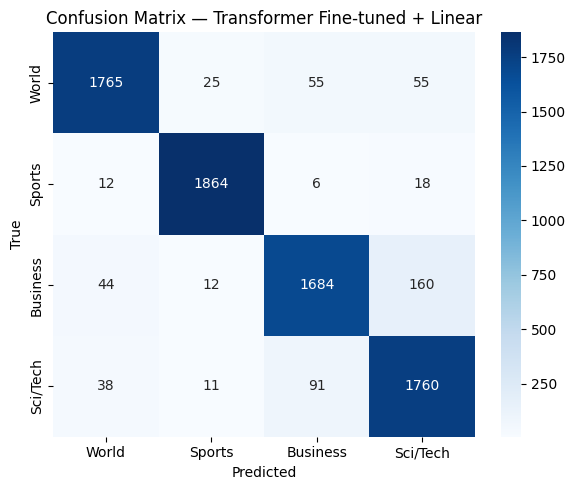

In [ ]:
plot_confusion_matrix(
    ft_results['confusion_matrix'],
    AG_NEWS_CLASSES,
    title='Confusion Matrix - Transformer Fine-tuned + Linear',
    save_path='../outputs/plots/part3_confusion_matrix.png',
)

## 8b. t-SNE Visualization of Frozen Features

Visualize feature quality by projecting extracted features to 2D.

c:\Users\ngjun\anaconda3\envs\tictag\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\ngjun\anaconda3\envs\tictag\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\ngjun\anaconda3\envs\tictag\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


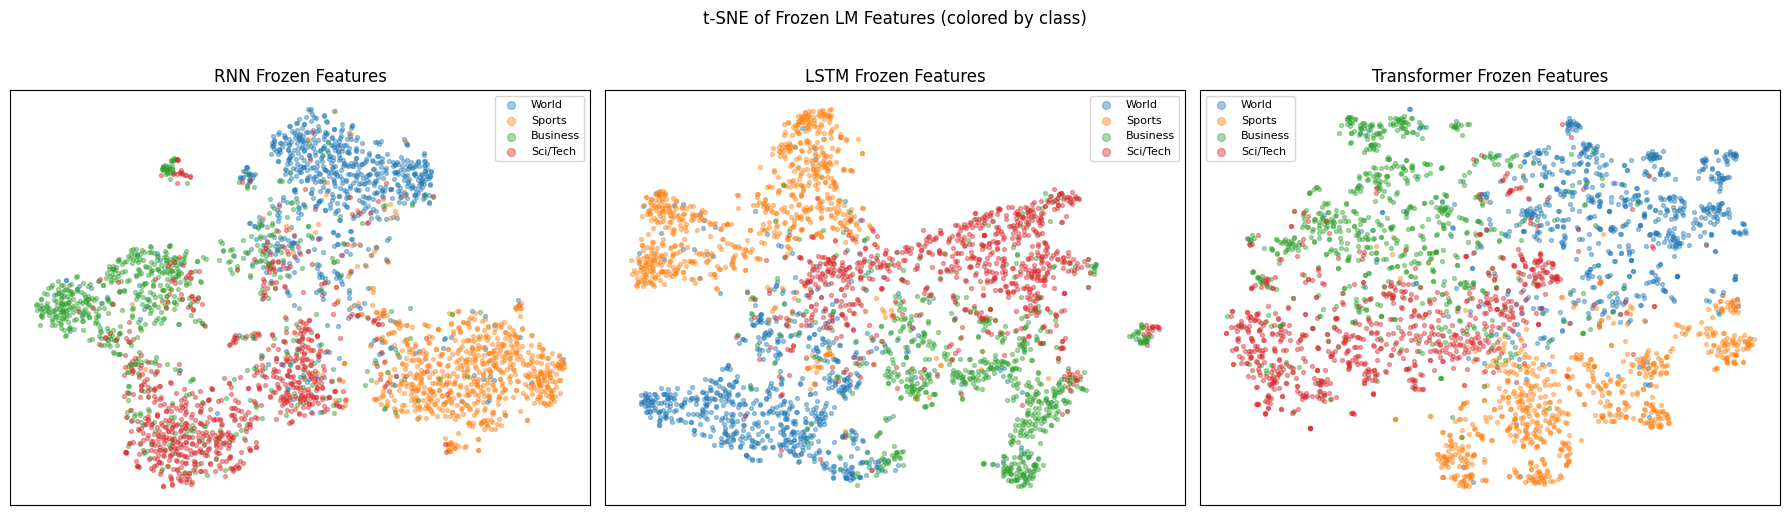

In [21]:
from sklearn.manifold import TSNE

# t-SNE on test features (subsample for speed)
n_tsne = 3000
rng = np.random.RandomState(42)
idx = rng.choice(len(tf_test_feats), n_tsne, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for ax, (name, feats, labels) in zip(axes, [
    ('RNN', rnn_test_feats, rnn_test_labels),
    ('LSTM', lstm_test_feats, lstm_test_labels),
    ('Transformer', tf_test_feats, tf_test_labels),
]):
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
    emb_2d = tsne.fit_transform(feats[idx])
    
    for cls_idx, cls_name in enumerate(AG_NEWS_CLASSES):
        mask = labels[idx] == cls_idx
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=colors[cls_idx],
                  label=cls_name, alpha=0.4, s=8)
    ax.set_title(f'{name} Frozen Features')
    ax.legend(fontsize=8, markerscale=2)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('t-SNE of Frozen LM Features (colored by class)', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/plots/part3_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

## 8c. Cross-Part Analysis: LM Perplexity vs Downstream Accuracy

Does a better language model produce better downstream features? Plot test perplexity (Part I) against frozen linear probe accuracy.

c:\Users\ngjun\anaconda3\envs\tictag\Lib\site-packages\torch\nn\functional.py:5109: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  warnings.warn(


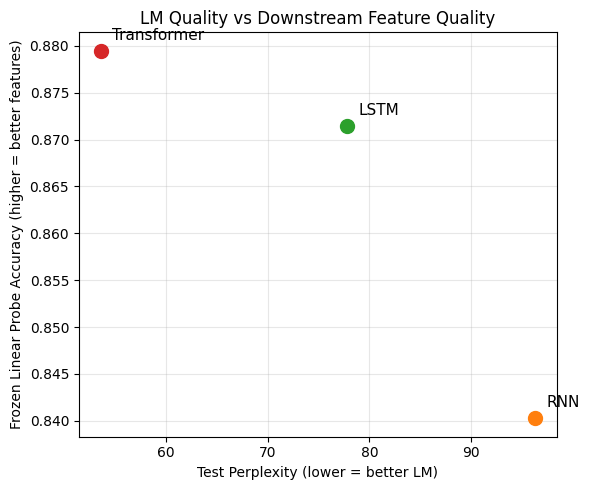

RNN:         PPL=96.26, Acc=0.8403
LSTM:        PPL=77.82, Acc=0.8714
Transformer: PPL=53.59, Acc=0.8795


In [22]:
# Cross-part analysis: Perplexity vs Downstream Accuracy
from src.utils import compute_perplexity
from src.data import build_lm_dataloaders

lm_train_dl, lm_val_dl, lm_test_dl = build_lm_dataloaders(
    data,
    batch_size=cfg_ds['batch_size'],
    max_seq_len=cfg_data['max_seq_len'],
)

rnn_ppl = compute_perplexity(rnn_model, lm_test_dl, device)
lstm_ppl = compute_perplexity(lstm_model, lm_test_dl, device)
tf_ppl = compute_perplexity(tf_model, lm_test_dl, device)

# Frozen linear probe accuracies
rnn_acc = rnn_linear_results['accuracy']
lstm_acc = lstm_linear_results['accuracy']
tf_acc = tf_linear_results['accuracy']

fig, ax = plt.subplots(figsize=(6, 5))
models = ['RNN', 'LSTM', 'Transformer']
ppls = [rnn_ppl, lstm_ppl, tf_ppl]
accs = [rnn_acc, lstm_acc, tf_acc]
model_colors = ['#ff7f0e', '#2ca02c', '#d62728']

for name, ppl, acc, color in zip(models, ppls, accs, model_colors):
    ax.scatter(ppl, acc, c=color, s=100, zorder=5)
    ax.annotate(name, (ppl, acc), textcoords="offset points", xytext=(8, 8), fontsize=11)

ax.set_xlabel('Test Perplexity (lower = better LM)')
ax.set_ylabel('Frozen Linear Probe Accuracy (higher = better features)')
ax.set_title('LM Quality vs Downstream Feature Quality')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/part3_ppl_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'RNN:         PPL={rnn_ppl:.2f}, Acc={rnn_acc:.4f}')
print(f'LSTM:        PPL={lstm_ppl:.2f}, Acc={lstm_acc:.4f}')
print(f'Transformer: PPL={tf_ppl:.2f}, Acc={tf_acc:.4f}')

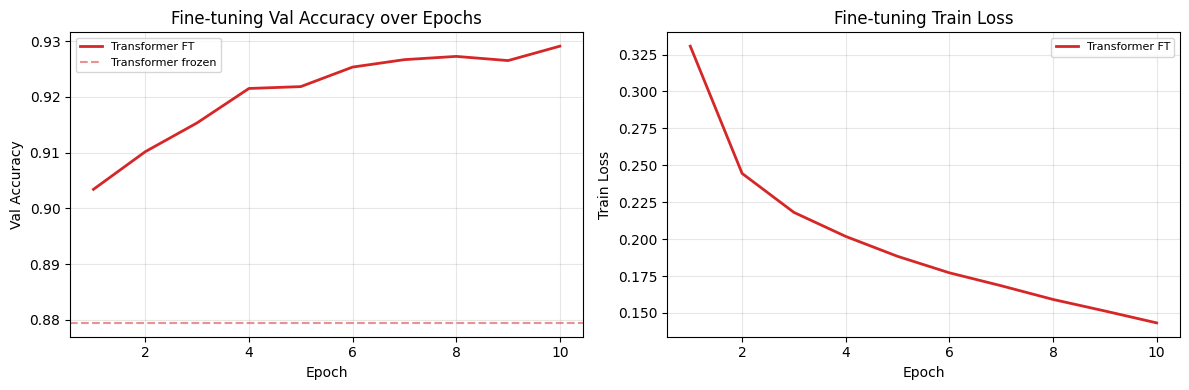

In [23]:
# Fine-tuning dynamics: val accuracy per epoch
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Val accuracy curve
ax = axes[0]
epochs_tf = range(1, len(ft_history['val_acc']) + 1)
ax.plot(epochs_tf, ft_history['val_acc'], label='Transformer FT', color='#d62728', linewidth=2)
ax.axhline(y=tf_linear_results['accuracy'], color='#d62728', linestyle='--', alpha=0.5, label='Transformer frozen')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val Accuracy')
ax.set_title('Fine-tuning Val Accuracy over Epochs')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Train loss curve
ax = axes[1]
ax.plot(epochs_tf, ft_history['train_loss'], label='Transformer FT', color='#d62728', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Train Loss')
ax.set_title('Fine-tuning Train Loss')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/part3_finetune_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Analysis

**BoW baseline is hard to beat with frozen features:**
BoW + LogReg achieves 90.2% accuracy, outperforming all frozen linear probes (RNN 84.0%, LSTM 87.1%, Transformer 88.0%). This is expected as topic classification is fundamentally about *which words appear* (Sports articles say "game, team, score"), and BoW captures this signal directly. Frozen LM features are optimized for next-token prediction, not class separation, so a simple linear head can't fully recover the classification signal.

**MLP closes the gap:**
Adding a nonlinear MLP head significantly improves performance, especially for the Transformer: frozen+MLP (90.6%) surpasses BoW (90.2%), while frozen+linear (88.0%) does not. This shows the Transformer's features contain class-discriminative information, but it's not linearly separable as the MLP's nonlinear decision boundaries are needed to extract it. The same pattern holds for RNN (+1.7%) and LSTM (+1.2%).

**Better LM = better features (mostly):**
Lower perplexity correlates with higher downstream accuracy: RNN (PPL 96.3, Acc 84.0%) < LSTM (PPL 77.8, Acc 87.1%) < Transformer (PPL 53.6, Acc 88.0%).

**Fine-tuning provides the biggest gain:**
Fine-tuning the Transformer end-to-end reaches 93.1% accuracy with a +5.1% improvement over frozen+linear and +2.5% over frozen+MLP. Fine-tuning adapts the entire representation space from "predict next word" to "separate 4 news topics," which is far more effective than just adding a better head on top of frozen features. Val accuracy improves monotonically across all 10 epochs (90.3% â†’ 92.9%), suggesting more epochs could help further.

**Per-class patterns:**
Sports is consistently the easiest class across all methods (F1 0.92 ~ 0.98), thanks to its distinctive vocabulary. Business is the hardest (F1 0.80 ~ 0.90), likely sharing vocabulary with World (trade, economy, policy) and Sci/Tech (companies, products). Fine-tuning improves the weakest classes most: Business F1 jumps from 0.84 (frozen+linear) to 0.90 (fine-tuned).